<a href="https://colab.research.google.com/github/olya-mashtalyar/statistical-practicum/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Serial test

Idea: break the sequence $x_1, x_2, x_3, ..., x_{2n}$ into consecutive series of length $2$: $(x_1, x_2), (x_3, x_4), ..., (x_{2n-1}, x_{2n})$ and look at each element as a random and independent point in $2D$ space. Next, apply chi-square. Similarly, one can construct series of length $3, 4$, etc.

### Problem 1
Implement serial test and apply to a `samples`

In [ ]:
# Your code here
import numpy as np
import scipy.stats as stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

def serial_test(samples, dimension=2, bins=10):
    n = len(samples)
    if n % dimension != 0:
        samples = samples[:n - (n % dimension)]

    n_points = len(samples) // dimension
    points = np.array([samples[i*dimension:(i+1)*dimension] for i in range(n_points)])

    hist, _ = np.histogramdd(points, bins=bins)
    expected = np.full(hist.shape, n_points / (bins ** dimension))

    chi_sq, p_value = stats.chisquare(hist.ravel(), expected.ravel())
    return chi_sq, p_value

# пример
rng.current = 1
samples = [rng() for _ in range(1000)]
chi_sq, p_value = serial_test(samples, dimension=2, bins=10)
print(f"chi_sq = {chi_sq:.4f}, p_value = {p_value:.4f}")

if p_value < 0.05:
    print("Отвергаем H₀: последовательность не случайна")
else:
    print("Не отвергаем H₀: последовательность случайна")


chi_sq = 100.4000, p_value = 0.4418
Не отвергаем H₀: последовательность случайна


### Permutation test

We again decompose the sequence $x_1, x_2, x_3, ..., x_{dn}$ into consecutive series of length $d$: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), \ldots, (x_{nd-d+1}, x_{nd})$. A series of $d$ elements can be ordered in $d!$ ways and each way of ordering is equally probable. Hence the idea of the test is to count how many times each ordering occurs among $n$ series and apply the $\chi^2$ test.

### Problem 2*
Implement permutation test and apply to a `samples`

In [ ]:
# Your code here

from itertools import permutations

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

def permutation_test(samples, d=3):
    n = len(samples)
    if n % d != 0:
        samples = samples[:n - (n % d)]

    n_blocks = len(samples) // d
    blocks = [samples[i*d:(i+1)*d] for i in range(n_blocks)]

    all_perms = list(permutations(range(d)))
    n_perms = len(all_perms)

    perm_to_idx = {perm: i for i, perm in enumerate(all_perms)}
    observed = np.zeros(n_perms, dtype=int)

    for block in blocks:
        perm = tuple(np.argsort(block))
        observed[perm_to_idx[perm]] += 1

    expected = np.full(n_perms, n_blocks / n_perms)
    chi_sq, p_value = stats.chisquare(observed, expected)

    return chi_sq, p_value

# пример
rng.current = 42
samples = [rng() for _ in range(1000)]
chi_sq, p_value = permutation_test(samples, d=3)
print(f"d=3: chi_sq = {chi_sq:.4f}, p_value = {p_value:.4f}")

if p_value < 0.05:
    print("Отвергаем H₀: последовательность не случайна")
else:
    print("Не отвергаем H₀: последовательность случайна")



d=3: chi_sq = 3.7748, p_value = 0.5823
Не отвергаем H₀: последовательность случайна


The choice of parameters $m$, $a$ and $c$ has a significant impact on the quality of the sequence. If the parameters are chosen unsuccessfully, it can lead to unexpected consequences:

In [ ]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
print("This sequence looks as random:")
random[:10]

This sequence looks as random:


[3.051897510886192e-05,
 0.00018310965970158577,
 0.0008239871822297573,
 0.003295936156064272,
 0.012359732296317816,
 0.04449496837332845,
 0.15573221957311034,
 0.533938602078706,
 0.8020416363142431,
 0.006802399177104235]

The histogram of the distribution is similar to a uniform distribution:

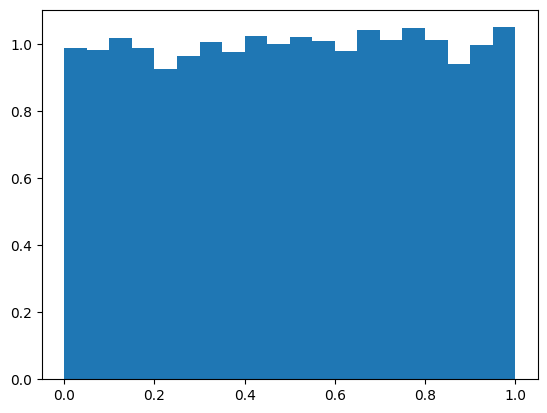

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure()

plt.hist(random, 20, density=True)
plt.show()

However, the series test shows that the points are located on hyperplanes, which does not fit well with the notion of randomness:

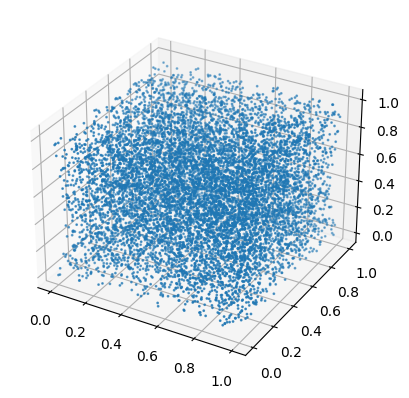

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(random[::3], random[1::3], random[2::3], s=1)
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(x=random[::3], y=random[1::3], z=random[2::3], opacity=0.1)
fig.update_traces(marker_size = 2)
fig.show()

### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [ ]:
# Your code here
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
random_good = [rng() for _ in range(30000)]

import plotly.express as px

fig = px.scatter_3d(x=random[::3], y=random[1::3], z=random[2::3], opacity=0.1)
fig.update_traces(marker_size = 2)
fig.show()


fig = px.scatter_3d(x=random_good[::3], y=random_good[1::3], z=random_good[2::3], opacity=0.1)
fig.update_traces(marker_size = 2)
fig.show()

Замечаем, что rng_bad имеет эффект решетки, а rng нет

### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

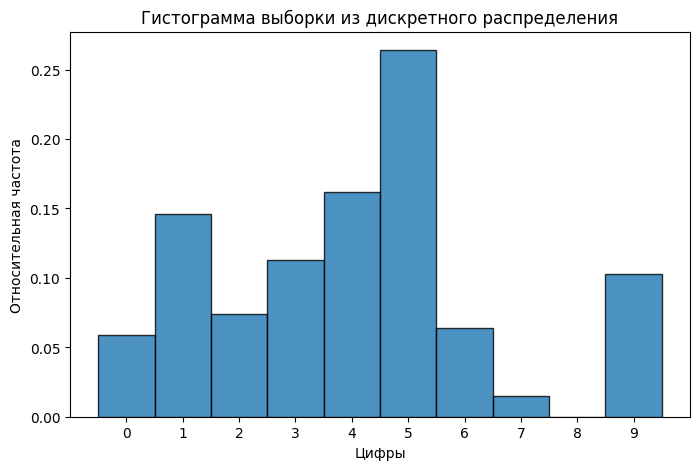

In [ ]:
# Your code here
import matplotlib.pyplot as plt

digits = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

weights /= weights.sum()

a = np.cumsum(weights)
b = np.random.rand(1000)
c = np.searchsorted(a, b)

plt.figure(figsize=(8, 5))
plt.hist(c, bins=np.arange(11) - 0.5, density=True, alpha=0.8, edgecolor='black')
plt.xticks(digits)
plt.xlabel("Цифры")
plt.ylabel("Относительная частота")
plt.title("Гистограмма выборки из дискретного распределения")
plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

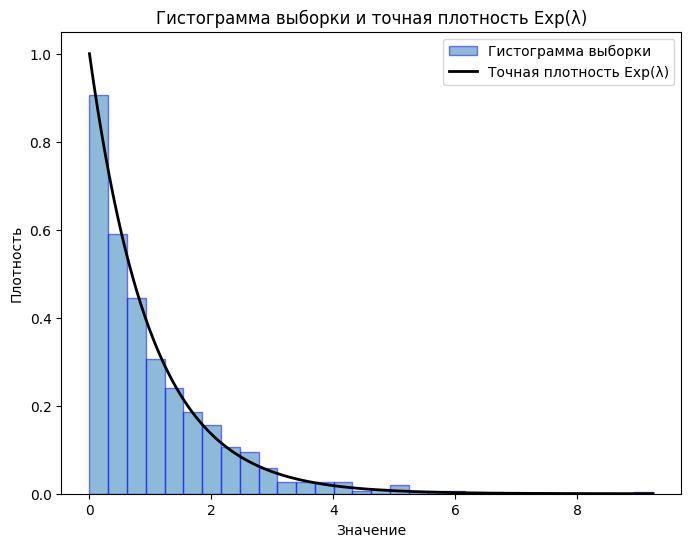

In [ ]:
# Your code here
par = 1.0
n = 1000
m = np.random.rand(n)

#Метод обратного преобразования
f = -np.log(m) / par

plt.figure(figsize=(8, 6))
plt.hist(f, bins=30, density=True, edgecolor='b', alpha=0.5, label='Гистограмма выборки')
x = np.linspace(0, np.max(f), 1000) #точная плотность экспоненциального распределения
pdf = par * np.exp(-par * x)

plt.plot(x, pdf, color='black', lw=2, label='Точная плотность Exp(λ)')
plt.title('Гистограмма выборки и точная плотность Exp(λ)')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

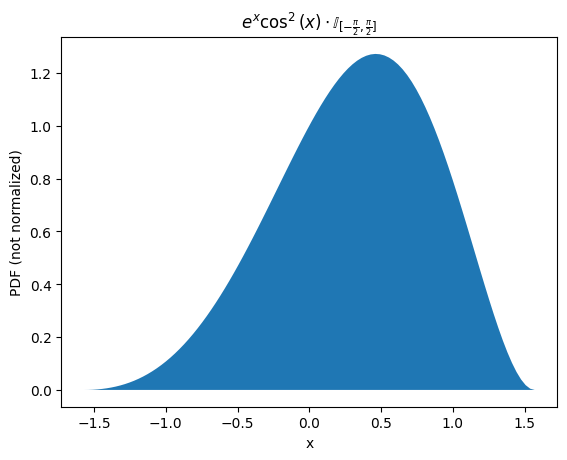

In [ ]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

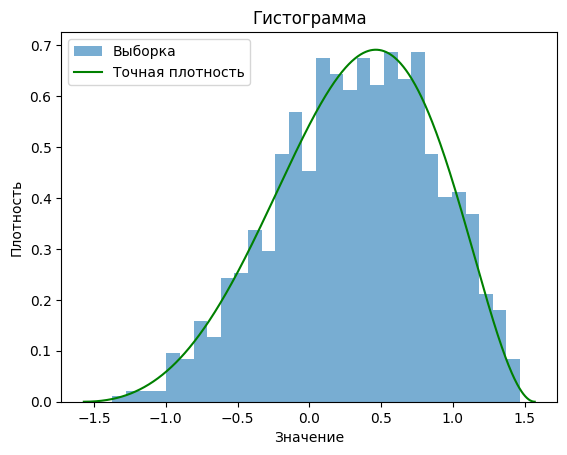

In [ ]:
# Your code here
from scipy.integrate import quad

#Ненормированная плотность вероятности
def func(x):
    return np.exp(x) * np.cos(x)**2

#Вычислим нормировочную константу
integral, error = quad(func, -np.pi/2, np.pi/2)
C = 1 / integral

def density(x):
    return C * func(x)

#Метод принятия-отклонения
samples = []
while len(samples) < 1000:
    x = np.random.uniform(-np.pi/2, np.pi/2)
    y = np.random.uniform(0, 1 / np.pi)*2
    if y <= density(x):
        samples.append(x)

samples = np.array(samples)

plt.hist(samples, bins=30, density=True, alpha=0.6, label='Выборка')

x_values = np.linspace(-np.pi/2, np.pi/2, 1000)
density_values = density(x_values)

plt.plot(x_values, density_values, 'green', label='Точная плотность')
plt.title('Гистограмма')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

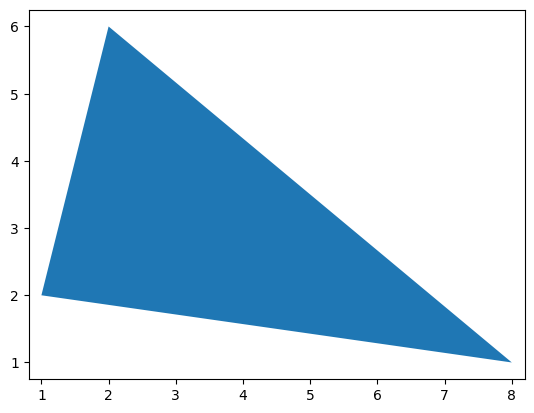

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

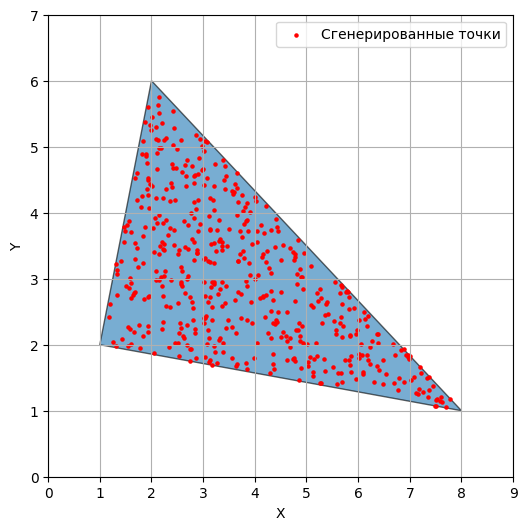

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

N = 500
u = np.random.rand(N)
v = np.random.rand(N)

#Барицентрические координаты
s = np.sqrt(u)
x = (1 - s) * A[0] + s * (1 - v) * B[0] + s * v * C[0]
y = (1 - s) * A[1] + s * (1 - v) * B[1] + s * v * C[1]


fig, ax = plt.subplots(figsize=(6, 6))
polygon = Polygon([A, B, C], closed=True, edgecolor='black', alpha=0.6)
ax.add_patch(polygon)
ax.scatter(x, y, color='red', s=5, label="Сгенерированные точки")

ax.set_xlim(min(A[0], B[0], C[0]) - 1, max(A[0], B[0], C[0]) + 1)
ax.set_ylim(min(A[1], B[1], C[1]) - 1, max(A[1], B[1], C[1]) + 1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.grid()
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

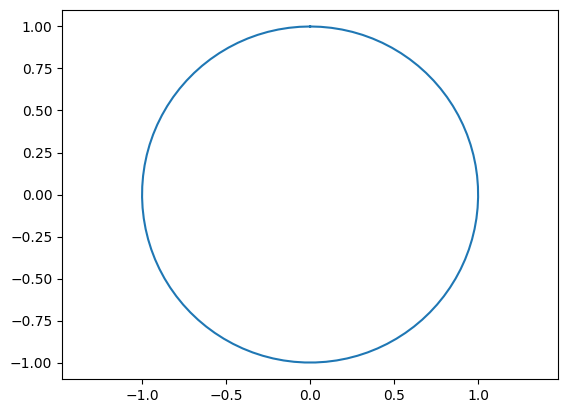

In [ ]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

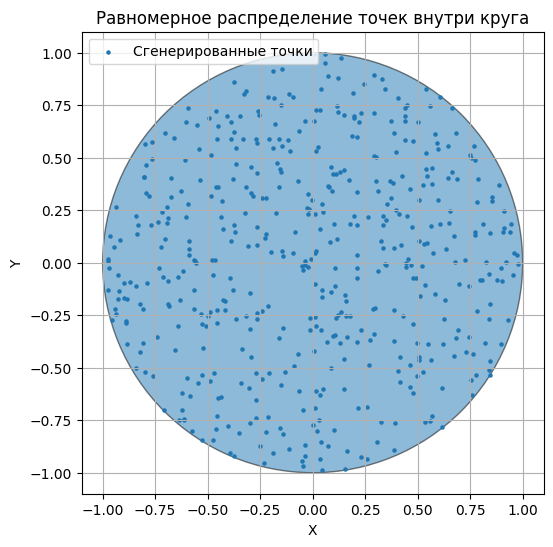

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

n = 500
theta = np.random.uniform(0, 2 * np.pi, n)
r = np.sqrt(np.random.uniform(0, 1, n))  # sqrt обеспечивает равномерность по площади

#Переводим в декартовы координаты
x = r * np.cos(theta)
y = r * np.sin(theta)

fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), 1, alpha=0.5, edgecolor='black')
ax.add_patch(circle)
ax.scatter(x, y, s=5, label="Сгенерированные точки")

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Равномерное распределение точек внутри круга")
ax.legend()
ax.set_aspect('equal')
plt.grid()
plt.show()

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [ ]:
import seaborn as sns

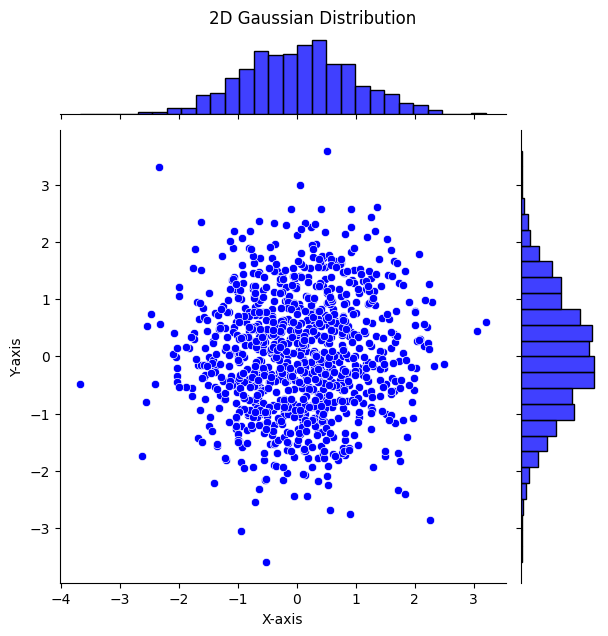

In [ ]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()

Среднее значение выборки: 
[4.14081444 6.69332345]
Выборочная ковариационная матрица: 
[[20.72798168 -3.47188526]
 [-3.47188526 42.44711397]]


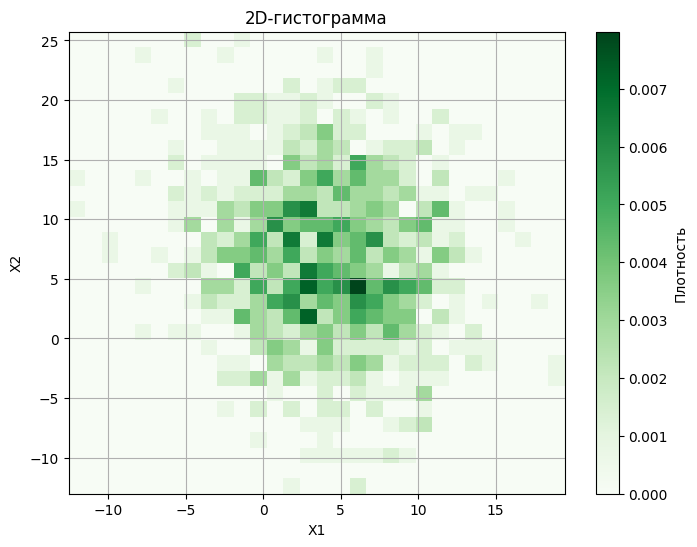

In [ ]:
# Your code here
#Функция генерации двух независимых стандартных нормальных величин
def func(n):
    s = []
    while len(s) < n:
        U, V = np.random.uniform(-1, 1, 2)
        S = U**2 + V**2
        if S >= 1 or S == 0:  #отбрасываем точки, которые попадают за круг
            continue
        factor = np.sqrt(-2 * np.log(S) / S)
        s.append(U * factor)
        s.append(V * factor)
    return np.array(s[:n])  #убираем лишние значения (если n нечетное)


mu = np.array([4, 7])
sigma = np.array([[20, -4], [-4, 40]])

#Разложение Холецкого ковариационной матрицы
L = np.linalg.cholesky(sigma)
Z = func(2 * 1000).reshape(1000, 2)

#Преобразование к требуемому распределению
X = mu + Z @ L.T

s_mean = np.mean(X, axis=0)
cov = np.cov(X, rowvar=False)

print(f"Среднее значение выборки: \n{s_mean}")
print(f"Выборочная ковариационная матрица: \n{cov}")

plt.figure(figsize=(8, 6))
plt.hist2d(X[:, 0], X[:, 1], bins=30, cmap='Greens', density=True)
plt.colorbar(label="Плотность")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("2D-гистограмма")
plt.grid(True)
plt.show()